# Bước 07: So Sánh Toàn Diện & Đánh Giá Duy Nhất Một Lần Trên Tập Test Niêm Phong
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers
Nguồn tham chiếu: `srcs/05_machine_learning/Forcasting_v3/11_evaluate_final_test.py`

**ĐẶC BIỆT: TỰ ĐỘNG SO SÁNH CẢ 2 BỘ ĐẶC TRƯNG (`full` CÓ lag_1 VS `no_lag1` KHÔNG lag_1)**
- Notebook này tự động quét **tất cả các mô hình đã huấn luyện** (MSE, MAE, Huber x Full Features & No_Lag1).
- So sánh công bằng chỉ số WAPE trên tập Validation (phạm vi chính thức Ban ngày Measured & Daylight).
- Tự động chọn ra **Mô hình Vô địch Tuyệt đối** cho từng Horizon ($h1$ và $h4$) để chấm điểm 1 lần duy nhất trên tập Test niêm phong!

## Bước 2. Import thư viện và khai báo tham số

In [1]:
# ── Gioi han thread: may i5-12450HX co 8 core / 12 thread (4 P-core + 4 E-core).
# Dung het 12 thread lam cac thread tranh nhau va CHAM HON. Dat 6 de bam P-core,
# con lai de cho Jupyter va he dieu hanh. Phai set TRUOC khi numpy nap moi co tac dung.
import os

for _bien in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
              'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_bien, '6')

import gc
import json
import os
import pickle
import platform
import time
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

try:
    display
except NameError:
    display = print

VERSION = 'v5'
SITE_COL = 'site_id'
TIMESTAMP_COL = 'timestamp'
TARGET_COL = 'energy_generated_kwh'
HORIZONS = [1, 4]

USE_GPU = True
GPU_PLATFORM_ID = 0
GPU_DEVICE_ID = 0

SELECTED_DIR = '../../data/model/v5/05_selected'
TRAIN_BASE_DIR = '../../data/model/v5/06_train'
OUTPUT_DIR = '../../data/model/v5/07_final_test'
os.makedirs(OUTPUT_DIR, exist_ok=True)
for h in HORIZONS:
    os.makedirs(f'{OUTPUT_DIR}/h{h}', exist_ok=True)

print("Đã import thư viện và khai báo tham số cho Notebook 07.")
print(f"- Horizons đánh giá: {HORIZONS}")
print(f"- Ghi kết quả ra   : {OUTPUT_DIR}")


Đã import thư viện và khai báo tham số cho Notebook 07.
- Horizons đánh giá: [1, 4]
- Ghi kết quả ra   : ../../data/model/v5/07_final_test


## Bước 2.1. Thiết lập GPU (OpenCL) cho LightGBM

In [2]:
LA_LINUX = (os.name == "posix" and platform.system() == "Linux")

if LA_LINUX:
    OCL_CANDIDATES = [
        "/run/opengl-driver/etc/OpenCL/vendors",
        "/etc/OpenCL/vendors",
    ]
    if "OCL_ICD_VENDORS" not in os.environ:
        for _p in OCL_CANDIDATES:
            if os.path.isdir(_p) and any(f.endswith(".icd") for f in os.listdir(_p)):
                os.environ["OCL_ICD_VENDORS"] = _p
                print("Đã tự đặt OCL_ICD_VENDORS = " + str(_p))
                break


def kiem_tra_gpu():
    try:
        X = np.random.rand(100, 4)
        y = np.random.rand(100)
        lgb.train(
            {"objective": "regression", "device": "gpu", "gpu_platform_id": GPU_PLATFORM_ID, "gpu_device_id": GPU_DEVICE_ID, "verbose": -1},
            lgb.Dataset(X, y),
            num_boost_round=1
        )
        return True, ""
    except Exception as e:
        return False, str(e)[:200]

GPU_SAN_SANG = False
if USE_GPU:
    GPU_SAN_SANG, _err = kiem_tra_gpu()
    if GPU_SAN_SANG:
        print("GPU OpenCL sẵn sàng.")
    else:
        print("[CẢNH BÁO] Không dùng được GPU, chuyển sang CPU.")

print("Chế độ tính toán: " + ("GPU" if GPU_SAN_SANG else "CPU"))

Đã tự đặt OCL_ICD_VENDORS = /run/opengl-driver/etc/OpenCL/vendors
GPU OpenCL sẵn sàng.
Chế độ tính toán: GPU


## Bước 3. Tự Động Quét & So Sánh Toàn Bộ Các Mô Hình (Cả Có Lag và Không Lag)

In [3]:
loss_list = ['mse', 'mae', 'huber']
# Tu khi notebook 03_1 dat LAGS = (96,), moi model deu KHONG con lag_1/lag_4 nua
# (khong con ban 'co lag_1' de so sanh). Chi giu feature_sets = [''] de tuong thich
# cau truc thu muc 06_train/{loss}/h{horizon}/ hien tai; 'no_lag1' chi con y nghia
# lich su, se tu dong bo qua neu khong tim thay thu muc.
feature_sets = ['', 'no_lag1']

winning_models_summary = {}

for h in HORIZONS:
    h_label = f"h{h}"
    h_desc = "t+1 (15m tới)" if h == 1 else "t+4 (1h tới)"
    val_summary = []

    print("")
    print("=" * 80)
    print(f"--- BẢNG SO SÁNH TOÀN BỘ CÁC MÔ HÌNH FOR {h_label.upper()} ({h_desc}) ---")
    print("=" * 80)

    for f_set in feature_sets:
        for l_name in loss_list:
            folder_name = f"{l_name}_{f_set}" if f_set else l_name
            val_json_path = f'{TRAIN_BASE_DIR}/{folder_name}/{h_label}/metrics_val.json'

            if not os.path.exists(val_json_path):
                val_json_path = f'{TRAIN_BASE_DIR}/{folder_name}/metrics_val.json'

            if not os.path.exists(val_json_path):
                continue

            with open(val_json_path, 'r', encoding='utf-8') as f:
                data = json.load(f)

            if h_label in data:
                data = data[h_label]

            meas_day_m = data.get('measured_daylight', data.get('scope_c_measured_daylight_official', {}))
            meas_m = data.get('measured', data.get('scope_b_measured', {}))
            all_m = data.get('all', data.get('scope_a_all', {}))

            val_summary.append({
                'horizon': h_label,
                'loss_name': l_name.upper(),
                'feature_set': f_set if f_set else 'chuan (lag_96, khong lag_1/lag_4)',
                'raw_f_set': f_set,
                'folder': folder_name,
                'pooled_wape_cv_%': data.get('pooled_wape_cv'),
                'val_measured_daylight_wape_%': meas_day_m.get('wape'),
                'val_measured_daylight_rmse': meas_day_m.get('rmse'),
                'val_measured_daylight_mae': meas_day_m.get('mae'),
                'val_measured_daylight_r2': meas_day_m.get('r2'),
            })

    if not val_summary:
        print(f"[CANH BAO] Chua co ket qua train cho {h_label} tai {TRAIN_BASE_DIR}, bo qua horizon nay.")
        print("           Muon co h4 thi dat HORIZON_STEPS = 4 trong notebook 06_1 roi chay lai.")
        continue

    df_val_comp = pd.DataFrame(val_summary)
    display(df_val_comp[['horizon', 'loss_name', 'feature_set', 'val_measured_daylight_wape_%', 'val_measured_daylight_rmse', 'val_measured_daylight_r2']])

    best_idx = df_val_comp['val_measured_daylight_wape_%'].idxmin()
    best_loss_name = df_val_comp.loc[best_idx, 'loss_name'].lower()
    best_f_set = df_val_comp.loc[best_idx, 'raw_f_set']
    best_f_label = df_val_comp.loc[best_idx, 'feature_set']
    best_folder = df_val_comp.loc[best_idx, 'folder']
    best_val_wape = df_val_comp.loc[best_idx, 'val_measured_daylight_wape_%']

    rationale_str = f"Horizon {h_label.upper()}: Mô hình VÔ ĐỊCH là '{best_loss_name.upper()}' ({best_f_label}) với Validation Measured & Daylight WAPE = {best_val_wape:.2f}%."
    print(f"=> MÔ HÌNH VÔ ĐỊCH DÀNH CHO {h_label.upper()}: Loss = {best_loss_name.upper()} | Bộ đặc trưng = {best_f_label} (WAPE = {best_val_wape:.2f}%)")

    winning_models_summary[h_label] = {
        'winning_loss': best_loss_name,
        'feature_set_name': best_f_set,
        'feature_set_label': best_f_label,
        'folder_name': best_folder,
        'rationale': rationale_str,
        'val_wape': best_val_wape,
        'comparison': val_summary,
    }

with open(f'{OUTPUT_DIR}/best_loss.json', 'w', encoding='utf-8') as f:
    json.dump(winning_models_summary, f, ensure_ascii=False, indent=2)

print("")
print(f"Đã lưu kết quả so sánh và mô hình vô địch vào: {OUTPUT_DIR}/best_loss.json")



--- BẢNG SO SÁNH TOÀN BỘ CÁC MÔ HÌNH FOR H1 (t+1 (15m tới)) ---


,horizon,loss_name,feature_set,val_measured_daylight_wape_%,val_measured_daylight_rmse,val_measured_daylight_r2
0,h1,MSE,"chuan (lag_96, khong lag_1/lag_4)",22.476075,3.595455,0.902548
1,h1,MAE,"chuan (lag_96, khong lag_1/lag_4)",21.955019,3.610608,0.901725
2,h1,HUBER,"chuan (lag_96, khong lag_1/lag_4)",22.320441,3.606091,0.901971


=> MÔ HÌNH VÔ ĐỊCH DÀNH CHO H1: Loss = MAE | Bộ đặc trưng = chuan (lag_96, khong lag_1/lag_4) (WAPE = 21.96%)

--- BẢNG SO SÁNH TOÀN BỘ CÁC MÔ HÌNH FOR H4 (t+4 (1h tới)) ---


,horizon,loss_name,feature_set,val_measured_daylight_wape_%,val_measured_daylight_rmse,val_measured_daylight_r2
0,h4,MSE,"chuan (lag_96, khong lag_1/lag_4)",27.118041,4.237327,0.870088
1,h4,MAE,"chuan (lag_96, khong lag_1/lag_4)",26.576369,4.251983,0.869188
2,h4,HUBER,"chuan (lag_96, khong lag_1/lag_4)",26.659730,4.255800,0.868953


=> MÔ HÌNH VÔ ĐỊCH DÀNH CHO H4: Loss = MAE | Bộ đặc trưng = chuan (lag_96, khong lag_1/lag_4) (WAPE = 26.58%)

Đã lưu kết quả so sánh và mô hình vô địch vào: ../../data/model/v5/07_final_test/best_loss.json


## Bước 4. Đánh giá Duy nhất Một Lần trên Tập Test Niêm Phong cho Mô hình Vô địch

In [4]:
def horizon_label_offset_steps(horizon_steps):
    # Convention da sua: dac trung tai t -> muc tieu tai t + h buoc (du bao that).
    # Truoc day h1 co source trung target nen du bao bi tre 1 buoc tren bieu do.
    return int(horizon_steps)


def label_timestamp_for_horizon(ts, horizon_steps):
    return pd.to_datetime(ts, errors='coerce') + pd.to_timedelta(
        horizon_label_offset_steps(horizon_steps) * 15,
        unit='m',
    )


def add_horizon_target(df, horizon_steps):
    out = df.copy()
    target_col_name = f'target_h{horizon_steps}'
    shift_steps = -horizon_label_offset_steps(horizon_steps)
    out[target_col_name] = out.groupby(SITE_COL)[TARGET_COL].shift(shift_steps)
    return out, target_col_name


# Cac cot dac trung "tai dinh" (tuc tinh tai thoi diem MUC TIEU T+h, khong phai thoi diem
# hien tai T) - duoc train sinh ra bang them_muc_tieu() (04_1/04_2/04_3.py) voi hau to _mt.
# Notebook nay tu tinh lai cac cot _mt (tap test khong con duoc notebook 06 xuat ra)
# dung cac cot nay bang shift(-h), neu khong se thieu dung 14 cot nay va LightGBM bao loi
# "number of features in data (40) is not the same as it was in training data (54)".
COT_TAT_DINH = [
    'solar_elevation', 'solar_azimuth', 'azimuth_sin', 'azimuth_cos', 'sin_elevation',
    'ghi_cs', 'ky_vong', 'ty_le_bao_hoa',
    'minute_of_day', 'hour_of_day', 'hour_bucket_model', 'hour', 'hour_sin', 'hour_cos',
    'minute', 'day', 'day_of_week', 'month', 'day_of_year', 'doy_sin', 'doy_cos',
]


test_path = f'{SELECTED_DIR}/{VERSION}_test_selected.parquet'
print(f"Đang đọc tập Test niêm phong từ: {test_path}")
test_raw = pd.read_parquet(test_path)

# ── Loc tap test DUNG Y HET cach notebook 06 loc tap development ──
# Bon dieu kien nay phai giong het, neu khong so dong khac nhau -> metric khac nhau.
# EXCLUDE_SITES: 2 tram co capacity_kw khong dang tin (site 19 vuot tran metadata 5,03 lan;
# site 24 vuot 1,77 lan), da bi loai khoi train nen cung phai loai khoi test.
EXCLUDE_SITES = [19, 24]
_n0 = len(test_raw)
test_base = test_raw
if 'exclude_from_training' in test_base.columns:
    test_base = test_base[test_base['exclude_from_training'] == False]
if 'has_complete_history_features' in test_base.columns:
    test_base = test_base[test_base['has_complete_history_features'] == True]
test_base = test_base.dropna(subset=[TARGET_COL])
if EXCLUDE_SITES:
    test_base = test_base[~test_base[SITE_COL].isin(EXCLUDE_SITES)]
test_base = test_base.sort_values([SITE_COL, TIMESTAMP_COL]).reset_index(drop=True)
print(f"Loc tap test: {_n0:,} -> {len(test_base):,} dong "
      f"(giong het 4 dieu kien loc cua notebook 06)")
del test_raw
gc.collect()

test_audit_df = test_base[[SITE_COL, TIMESTAMP_COL, 'energy_source', 'is_daylight']].copy() if 'is_daylight' in test_base.columns else test_base[[SITE_COL, TIMESTAMP_COL]].copy()

if not winning_models_summary:
    raise FileNotFoundError(
        "Chua tim thay ket qua train nao tai " + TRAIN_BASE_DIR + ". Hay chay notebook 06_1 truoc."
    )

for h in HORIZONS:
    h_label = f"h{h}"
    if h_label not in winning_models_summary:
        print(f"[BO QUA] {h_label} chua co mo hinh, khong cham diem tap test cho horizon nay.")
        continue
    h_desc = f"target +{horizon_label_offset_steps(h) * 15} phút theo convention train notebook 06"
    h_dir = f"{OUTPUT_DIR}/{h_label}"
    os.makedirs(h_dir, exist_ok=True)

    win_info = winning_models_summary[h_label]
    win_loss = win_info['winning_loss']
    win_f_set = win_info['feature_set_name']
    folder_name = win_info['folder_name']

    win_model_dir = f'{TRAIN_BASE_DIR}/{folder_name}/{h_label}'
    if not os.path.exists(f'{win_model_dir}/model.pkl'):
        win_model_dir = f'{TRAIN_BASE_DIR}/{folder_name}'

    with open(f'{win_model_dir}/model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open(f'{win_model_dir}/model_config.json', 'r', encoding='utf-8') as f:
        m_config = json.load(f)

    configured_horizon = int(m_config.get('horizon_steps', -1))
    if configured_horizon != h:
        raise ValueError(
            f'Model config sai horizon: đang đánh giá h{h} nhưng model khai báo h{configured_horizon}'
        )

    features = m_config['features']
    feature_medians = pd.Series(m_config['feature_medians'], dtype=float)

    t_col = f'target_h{h}'
    # ── Notebook nay TU DUNG ma tran test, khong doc file tu notebook 06 ──
    # Tu 2026-08-07, notebook 06 khong con mo tap test nua (tap test bi NIEM PHONG den
    # day). Vi vay 07 phai tu dung ma tran, bang DUNG cac phep bien doi ma 06 da dung:
    #   - dich cac cot TAT DINH sang T+h thanh cot hau to _mt (shift(-h) theo tung site)
    #   - muc tieu y = target shift(-h)
    # Thieu buoc _mt thi chi con 40/54 dac trung -> LightGBM bao loi so cot khong khop.
    print(f"   Tu dung ma tran test tu: {test_path}")
    test_full = test_base.copy()
    g_full = test_full.groupby(SITE_COL)
    for c in COT_TAT_DINH:
        mt_col = f'{c}_mt'
        if mt_col in features and c in test_full.columns and mt_col not in test_full.columns:
            test_full[mt_col] = g_full[c].shift(-h)

    target = test_full.groupby(SITE_COL)[TARGET_COL].shift(-h)

    # FIX (hop dong tam du bao): cac dieu kien loc o tren lam luoi thoi gian khong con
    # lien tuc, nen groupby.shift(-h) co the tro toi "dong hop le thu h tiep theo" chu
    # khong phai moc T + h*15 phut. Bat buoc moc nhan phai dung tam, sai thi loai.
    _ts_nguon = pd.to_datetime(test_full[TIMESTAMP_COL], errors='coerce')
    _ts_nhan = pd.to_datetime(g_full[TIMESTAMP_COL].shift(-h), errors='coerce')
    _dung_tam = (_ts_nhan - _ts_nguon) == pd.Timedelta(minutes=15 * h)
    _n_sai_tam = int((target.notna() & ~_dung_tam).sum())
    keep_target = target.notna() & _dung_tam
    print(f"   Nhan khong nam dung tai T+{15 * h} phut (da loai): {_n_sai_tam:,} dong")

    # FIX (dong bo voi notebook 06): pham vi cham diem phai bam NHAN tai T+h, khong phai
    # dong nguon tai T. Notebook 06 da dich provenance sang moc nhan bang tien to 'nhan_'
    # roi moi loc; 07 truoc day quen buoc nay nen mat na roi ve cot chua dich, khien nhan
    # etl_imputed va nhan ban dem lot vao pham vi "do that ban ngay".
    # 2026-08-19: them 'outlier_group' de mask (c) dong bo voi headline cua notebook 06
    for _c in ('energy_source', 'is_daylight', 'outlier_group'):
        if _c in test_full.columns:
            test_full[f'nhan_{_c}'] = g_full[_c].shift(-h)

    metadata_cols = [SITE_COL, TIMESTAMP_COL, TARGET_COL, 'energy_source', 'is_daylight',
                     'nhan_energy_source', 'nhan_is_daylight', 'nhan_outlier_group',
                     'site_scale', 'sin_elevation', 'tran_cong_suat']
    required_cols = list(dict.fromkeys(features + metadata_cols))
    required_cols = [c for c in required_cols if c in test_full.columns]
    scored = test_full.loc[keep_target, required_cols].copy()
    scored[t_col] = target.loc[keep_target].to_numpy()
    # Moc thoi gian THUC TE cua dong bi shift toi - de file audit kiem chung duoc tam
    # du bao, thay vi cong co hoc source_timestamp + h*15 phut.
    scored['moc_nhan'] = _ts_nhan.loc[keep_target].to_numpy()
    del test_full
    gc.collect()

    missing_after = [c for c in features if c not in scored.columns]
    if missing_after:
        raise KeyError(
            f"Thieu {len(missing_after)} dac trung khong tai tao duoc: {missing_after[:6]}. "
            f"Kiem lai notebook 05 co chon dung bo dac trung nay khong.")

    feat_cols = [c for c in features if c in scored.columns]
    num_cols = [c for c in feat_cols if pd.api.types.is_numeric_dtype(scored[c])]
    feat_cols = num_cols

    X_test = scored[feat_cols].fillna(feature_medians).astype(float)
    y_true = scored[t_col].values
    y_pred_tho = model.predict(X_test)

    # Neu model train tren muc tieu da chuan hoa thi phai nhan nguoc mau va chan tran cong suat
    if m_config.get('chuan_hoa') and {'site_scale', 'sin_elevation'} <= set(scored.columns):
        _eps = float(m_config.get('eps_elev', 0.05))
        _mau = scored['site_scale'] * scored['sin_elevation'].clip(lower=_eps)
        # Nguong cat PHAI lay tu artifact, khong duoc viet cung: tu 2026-08-13 no duoc
        # suy tu phan vi 99 cua k tren tap TRAIN nen moi cau hinh mot khac. Thieu thi
        # dung ngay, vi cham diem bang nguong khac luc train la so sai.
        if 'clip_k' not in m_config:
            raise KeyError(
                f'model_config.json cua {win_model_dir} thieu clip_k. '
                'Hay chay lai notebook 06 de sinh artifact co nguong cat.')
        _clip_k = float(m_config['clip_k'])
        y_pred = np.clip(y_pred_tho, 0, _clip_k) * _mau.to_numpy()
        _cot_tran = m_config.get('cot_tran', 'tran_cong_suat')
        if _cot_tran in scored.columns:
            y_pred = np.minimum(y_pred, scored[_cot_tran].to_numpy() * 1.02)
        y_pred = np.where(scored['sin_elevation'].to_numpy() <= _eps, 0.0, y_pred)
        print(f"   Đã nhân ngược mẫu chuẩn hoá và chặn trần công suất cho {h_label}")
    else:
        y_pred = y_pred_tho

    scored['y_true'] = y_true
    scored['y_pred'] = y_pred
    scored['residual'] = y_true - y_pred

    # Baseline persistence: du bao y(T+h) bang chinh gia tri hien tai y(T).
    # Truoc day lay cot lag_1, nhung notebook 03-1 da bo lag ngan nen dung TARGET_COL.
    if TARGET_COL in scored.columns:
        scored['y_pred_baseline'] = scored[TARGET_COL].values
    elif 'lag_1' in scored.columns:
        scored['y_pred_baseline'] = scored['lag_1'].values
    else:
        scored['y_pred_baseline'] = np.nan

    def compute_wape_func(yt, yp):
        abs_y = np.nansum(np.abs(yt))
        return (np.nansum(np.abs(yt - yp)) / abs_y * 100.0) if abs_y > 0 else np.nan

    def compute_metrics_func(yt, yp):
        return {
            'wape': compute_wape_func(yt, yp),
            'rmse': root_mean_squared_error(yt, yp),
            'mae': mean_absolute_error(yt, yp),
            'r2': r2_score(yt, yp),
        }

    m_test_a = compute_metrics_func(y_true, y_pred)
    wape_base_a = compute_wape_func(y_true, scored['y_pred_baseline'].values) if scored['y_pred_baseline'].notna().any() else np.nan
    imprv_a = ((wape_base_a - m_test_a['wape']) / wape_base_a * 100.0) if pd.notna(wape_base_a) and wape_base_a > 0 else np.nan

    mask_meas = (scored['nhan_energy_source'] == 'measured').values if 'nhan_energy_source' in scored.columns else np.ones(len(scored), dtype=bool)
    m_test_b = compute_metrics_func(y_true[mask_meas], y_pred[mask_meas]) if mask_meas.sum() > 0 else {'wape': np.nan, 'rmse': np.nan, 'mae': np.nan, 'r2': np.nan}
    wape_base_b = compute_wape_func(y_true[mask_meas], scored['y_pred_baseline'].values[mask_meas]) if (scored['y_pred_baseline'].notna().any() and mask_meas.sum() > 0) else np.nan
    imprv_b = ((wape_base_b - m_test_b['wape']) / wape_base_b * 100.0) if pd.notna(wape_base_b) and wape_base_b > 0 else np.nan

    if 'nhan_is_daylight' in scored.columns:
        mask_day = (scored['nhan_is_daylight'] == True).values | (scored['nhan_is_daylight'] == 1).values
        mask_meas_day_cu = mask_meas & mask_day
        # Dong bo mask voi headline 06 (~physical_over_capacity). Da do truoc khi sua:
        # physical nam 100% o site 19+24 (da EXCLUDE) -> dieu kien nay doi 0 dong tren test.
        if 'nhan_outlier_group' in scored.columns:
            mask_khong_physical = (scored['nhan_outlier_group'].astype(str)
                                   != 'physical_over_capacity').values
        else:
            mask_khong_physical = np.ones(len(scored), dtype=bool)
        mask_meas_day = mask_meas_day_cu & mask_khong_physical
        _lech_mask = int(mask_meas_day_cu.sum() - mask_meas_day.sum())
        print(f"   Mask (c) dong bo voi 06: loai them {_lech_mask:,} dong "
              f"physical_over_capacity (ky vong 0)")
    else:
        mask_meas_day = np.zeros(len(scored), dtype=bool)

    m_test_c = compute_metrics_func(y_true[mask_meas_day], y_pred[mask_meas_day]) if mask_meas_day.sum() > 0 else {'wape': np.nan, 'rmse': np.nan, 'mae': np.nan, 'r2': np.nan}
    wape_base_c = compute_wape_func(y_true[mask_meas_day], scored['y_pred_baseline'].values[mask_meas_day]) if (scored['y_pred_baseline'].notna().any() and mask_meas_day.sum() > 0) else np.nan
    imprv_c = ((wape_base_c - m_test_c['wape']) / wape_base_c * 100.0) if pd.notna(wape_base_c) and wape_base_c > 0 else np.nan

    print("")
    print(f"================ BÁO CÁO ĐÁNH GIÁ TẬP TEST FOR {h_label.upper()} ({h_desc}) ================")
    print(f"Mô hình thắng: Loss {win_loss.upper()} ({win_info['feature_set_label']})")
    print(f"(a) ALL     : WAPE {m_test_a['wape']:.2f}% | Base {wape_base_a:.2f}% | Cải thiện {imprv_a:.2f}%")
    print(f"(b) MEASURED: WAPE {m_test_b['wape']:.2f}% | Base {wape_base_b:.2f}% | Cải thiện {imprv_b:.2f}%")
    print(f"(c) MEASURED & DAYLIGHT (CHÍNH THỨC): WAPE {m_test_c['wape']:.2f}% | Base {wape_base_c:.2f}% | Cải thiện {imprv_c:.2f}%")

    metrics_h_payload = {
        'horizon_steps': h,
        'winning_loss': win_loss,
        'feature_set_name': win_f_set,
        'total_test_rows': len(scored),
        'measured_test_rows': int(mask_meas.sum()),
        'measured_daylight_test_rows': int(mask_meas_day.sum()),
        'all': {**m_test_a, 'baseline_persistence_wape': wape_base_a, 'improvement_vs_baseline_pct': imprv_a},
        'measured': {**m_test_b, 'baseline_persistence_wape': wape_base_b, 'improvement_vs_baseline_pct': imprv_b},
        'measured_daylight': {**m_test_c, 'baseline_persistence_wape': wape_base_c, 'improvement_vs_baseline_pct': imprv_c},
    }
    with open(f'{h_dir}/metrics_overall.json', 'w', encoding='utf-8') as f:
        json.dump(metrics_h_payload, f, ensure_ascii=False, indent=2)

    site_rows = []
    use_mask = mask_meas_day if mask_meas_day.sum() > 0 else (mask_meas if mask_meas.sum() > 0 else np.ones(len(scored), dtype=bool))
    scored_site = scored[use_mask].copy()
    for s_id, grp in scored_site.groupby(SITE_COL, observed=True):
        sm = compute_metrics_func(grp['y_true'].values, grp['y_pred'].values)
        site_rows.append({'site_id': s_id, 'rows': len(grp), **sm})
    df_site = pd.DataFrame(site_rows)
    df_site.to_csv(f'{h_dir}/metrics_by_site.csv', index=False)

    # ── Snapshot ma tran test cho notebook 08 (SHAP) ──
    # Tap test chi duoc MO o notebook nay. Notebook 08 KHONG duoc tu mo lai test, no
    # dung lai snapshot nay. Truoc day 08 doc X_test_h1.parquet do notebook 06 ghi ra -
    # nhung 06 da thoi ghi file do tu khi khoa tap test, nen 08 doc phai file cu.
    # Danh sach cot lay y het pipeline s09b_cham_diem_test.py de hai ben doi chieu duoc.
    _cot_luu = list(dict.fromkeys(feat_cols + [
        c for c in (SITE_COL, TIMESTAMP_COL, 'plot_timestamp', TARGET_COL, 'y_true',
                    'energy_source', 'is_daylight', 'site_scale', 'sin_elevation',
                    'tran_cong_suat')
        if c in scored.columns
    ]))
    scored[_cot_luu].to_parquet(f'{h_dir}/X_test_h{h}.parquet', index=False)
    print(f"   Da ghi snapshot ma tran test: {h_dir}/X_test_h{h}.parquet "
          f"({len(scored):,} dong x {len(_cot_luu)} cot)")

    audit_sub = scored[[SITE_COL, TIMESTAMP_COL, 'moc_nhan', 'y_true', 'y_pred', 'residual']].copy()
    audit_sub[f'source_timestamp_h{h}'] = pd.to_datetime(audit_sub[TIMESTAMP_COL], errors='coerce')
    audit_sub[f'target_timestamp_h{h}'] = label_timestamp_for_horizon(audit_sub[TIMESTAMP_COL], h)
    # label_timestamp lay tu moc THUC TE cua dong bi shift toi (khong cong co hoc), nen
    # file audit doi chieu duoc hai cot nay de phat hien nhan lech tam.
    audit_sub[f'label_timestamp_h{h}'] = audit_sub['moc_nhan']
    audit_sub[f'plot_timestamp_h{h}'] = audit_sub['moc_nhan']
    audit_sub = audit_sub.drop(columns=['moc_nhan'])
    audit_sub = audit_sub.rename(columns={
        'y_true': f'y_true_h{h}',
        'y_pred': f'y_pred_h{h}',
        'residual': f'residual_h{h}',
    })
    test_audit_df = test_audit_df.merge(audit_sub, on=[SITE_COL, TIMESTAMP_COL], how='left')

test_audit_df.to_parquet(f'{OUTPUT_DIR}/prediction_audit.parquet', index=False)
print("")
print(f"Đã xuất file dự báo tổng hợp cả h1 và h4: {OUTPUT_DIR}/prediction_audit.parquet")


Đang đọc tập Test niêm phong từ: ../../data/model/v5/05_selected/v5_test_selected.parquet
Loc tap test: 510,468 -> 483,254 dong (giong het 4 dieu kien loc cua notebook 06)
   Tu dung ma tran test tu: ../../data/model/v5/05_selected/v5_test_selected.parquet
   Nhan khong nam dung tai T+15 phut (da loai): 2,906 dong
   Đã nhân ngược mẫu chuẩn hoá và chặn trần công suất cho h1
   Mask (c) dong bo voi 06: loai them 0 dong physical_over_capacity (ky vong 0)

================ BÁO CÁO ĐÁNH GIÁ TẬP TEST FOR H1 (target +15 phút theo convention train notebook 06) ================
Mô hình thắng: Loss MAE (chuan (lag_96, khong lag_1/lag_4))
(a) ALL     : WAPE 16.93% | Base 15.19% | Cải thiện -11.45%
(b) MEASURED: WAPE 17.51% | Base 16.20% | Cải thiện -8.11%
(c) MEASURED & DAYLIGHT (CHÍNH THỨC): WAPE 17.49% | Base 16.18% | Cải thiện -8.15%
   Da ghi snapshot ma tran test: ../../data/model/v5/07_final_test/h1/X_test_h1.parquet (480,308 dong x 59 cot)
   Tu dung ma tran test tu: ../../data/model/v5/0

## Bước 5. Trực quan hóa Tách Riêng 2 Đồ Thị (Mô hình Có Lag_1 vs Mô hình Không Lag_1)

--- KIỂM TRA ACTUAL VS PREDICT ĐÚNG TARGET TIMESTAMP ---


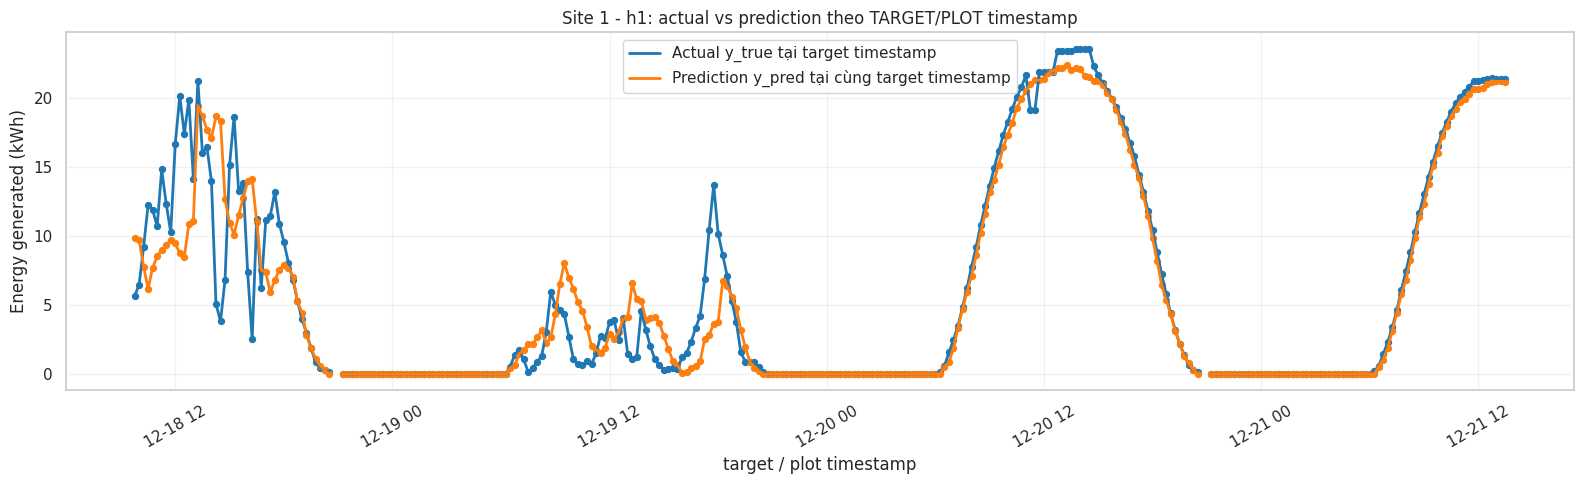

Quy ước timestamp:
- source_timestamp = thời điểm feature/input row
- target/plot_timestamp = thời điểm actual cần dự báo, dùng để so actual vs prediction
- h1 trong notebook 06 đang dùng offset 15 phút

Bảng đối chiếu timestamp actual vs predict:


,source_timestamp_h1,target_timestamp_h1,plot_timestamp_h1,actual_y_true,prediction_y_pred,abs_error
0,2021-12-18 09:30:00,2021-12-18 09:45:00,2021-12-18 09:45:00,5.6250,9.874878,4.249878
1,2021-12-18 09:45:00,2021-12-18 10:00:00,2021-12-18 10:00:00,6.4375,9.726905,3.289405
2,2021-12-18 10:00:00,2021-12-18 10:15:00,2021-12-18 10:15:00,9.1875,7.763015,1.424485
3,2021-12-18 10:15:00,2021-12-18 10:30:00,2021-12-18 10:30:00,12.2500,6.161248,6.088752
4,2021-12-18 10:30:00,2021-12-18 10:45:00,2021-12-18 10:45:00,11.8750,7.697722,4.177278
...,...,...,...,...,...,...
76,2021-12-19 04:45:00,2021-12-19 05:00:00,2021-12-19 05:00:00,0.0000,0.000000,0.000000
77,2021-12-19 05:00:00,2021-12-19 05:15:00,2021-12-19 05:15:00,0.0000,0.000000,0.000000
78,2021-12-19 05:15:00,2021-12-19 05:30:00,2021-12-19 05:30:00,0.0000,0.000000,0.000000
79,2021-12-19 05:30:00,2021-12-19 05:45:00,2021-12-19 05:45:00,0.0000,0.000000,0.000000


In [5]:
print("--- KIỂM TRA ACTUAL VS PREDICT ĐÚNG TARGET TIMESTAMP ---")

# Chọn case muốn soi. Đổi các tham số này khi cần trình bày.
PLOT_SITE_ID = 1 if 1 in set(test_audit_df[SITE_COL].dropna().astype(int).unique()) else test_audit_df[SITE_COL].dropna().iloc[0]
PLOT_HORIZON = 1 if 'y_true_h1' in test_audit_df.columns else 4
# Chi doi PLOT_HORIZON thu cong neu da chay ca 06_1 voi HORIZON_STEPS=4;
# lan chay nay chi co h1 (h4 bi bo qua o buoc so sanh phia tren).
PLOT_START = None  # ví dụ: '2022-01-06'
PLOT_DAYS = 2
MAX_POINTS = 300


def regular_time_grid_for_plot(df, ts_col, value_cols):
    if df.empty:
        return df[[ts_col] + value_cols].copy()
    start_ts = pd.to_datetime(df[ts_col]).min().floor('15min')
    end_ts = pd.to_datetime(df[ts_col]).max().ceil('15min')
    grid = pd.DataFrame({ts_col: pd.date_range(start_ts, end_ts, freq='15min')})
    values = (
        df[[ts_col] + value_cols]
        .drop_duplicates(ts_col, keep='last')
        .sort_values(ts_col)
    )
    return grid.merge(values, on=ts_col, how='left')


def plot_actual_vs_prediction_from_audit(audit_df, site_id, horizon, start=None, days=2, max_points=300):
    true_col = f'y_true_h{horizon}'
    pred_col = f'y_pred_h{horizon}'
    src_col = f'source_timestamp_h{horizon}'
    target_col = f'target_timestamp_h{horizon}'
    plot_col = f'plot_timestamp_h{horizon}'

    required = [SITE_COL, TIMESTAMP_COL, true_col, pred_col]
    missing = [c for c in required if c not in audit_df.columns]
    if missing:
        raise KeyError('Thiếu cột trong prediction_audit: ' + str(missing))

    df = audit_df[audit_df[SITE_COL].astype(str).eq(str(site_id))].dropna(subset=[true_col, pred_col]).copy()
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors='coerce')

    if src_col not in df.columns:
        df[src_col] = df[TIMESTAMP_COL]
    else:
        df[src_col] = pd.to_datetime(df[src_col], errors='coerce')

    if target_col not in df.columns:
        df[target_col] = label_timestamp_for_horizon(df[TIMESTAMP_COL], horizon)
    else:
        df[target_col] = pd.to_datetime(df[target_col], errors='coerce')

    if plot_col not in df.columns:
        df[plot_col] = df[target_col]
    else:
        df[plot_col] = pd.to_datetime(df[plot_col], errors='coerce')

    df = df.dropna(subset=[plot_col]).sort_values(plot_col)
    if start is not None:
        start_ts = pd.Timestamp(start)
        end_ts = start_ts + pd.Timedelta(days=days)
        df = df[df[plot_col].between(start_ts, end_ts)].copy()
    else:
        df = df.head(max_points).copy()

    plot_df = df[[src_col, target_col, plot_col, true_col, pred_col]].rename(
        columns={true_col: 'actual_y_true', pred_col: 'prediction_y_pred'}
    )
    grid_df = regular_time_grid_for_plot(plot_df, plot_col, ['actual_y_true', 'prediction_y_pred'])

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(grid_df[plot_col], grid_df['actual_y_true'], label='Actual y_true tại target timestamp', color='tab:blue', linewidth=2)
    ax.plot(grid_df[plot_col], grid_df['prediction_y_pred'], label='Prediction y_pred tại cùng target timestamp', color='tab:orange', linewidth=2)
    ax.scatter(plot_df[plot_col], plot_df['actual_y_true'], color='tab:blue', s=18)
    ax.scatter(plot_df[plot_col], plot_df['prediction_y_pred'], color='tab:orange', s=18)
    ax.set_title(f'Site {site_id} - h{horizon}: actual vs prediction theo TARGET/PLOT timestamp')
    ax.set_xlabel('target / plot timestamp')
    ax.set_ylabel('Energy generated (kWh)')
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    check = plot_df.copy()
    check['abs_error'] = (check['actual_y_true'] - check['prediction_y_pred']).abs()
    print('Quy ước timestamp:')
    print('- source_timestamp = thời điểm feature/input row')
    print('- target/plot_timestamp = thời điểm actual cần dự báo, dùng để so actual vs prediction')
    print(f'- h{horizon} trong notebook 06 đang dùng offset {horizon_label_offset_steps(horizon) * 15} phút')
    print('')
    print('Bảng đối chiếu timestamp actual vs predict:')
    display(check[[src_col, target_col, plot_col, 'actual_y_true', 'prediction_y_pred', 'abs_error']].head(80))


plot_actual_vs_prediction_from_audit(
    test_audit_df,
    site_id=PLOT_SITE_ID,
    horizon=PLOT_HORIZON,
    start=PLOT_START,
    days=PLOT_DAYS,
    max_points=MAX_POINTS,
)


### TỔNG KẾT VỀ VIỆC SO SÁNH MÔ HÌNH VÔ ĐỊCH
1. **Nguồn input của bảng so sánh:** Cell chọn mô hình vô địch đọc các file `metrics_val.json` trong `../../data/model/v5/06_train/{loss_or_feature_set}/h{horizon}/`.
2. **Phạm vi dữ liệu:** Với artifacts hiện có, notebook đang so sánh `huber` và `huber_no_lag1` cho `h1`/`h4`; các loss `mse` và `mae` chỉ xuất hiện nếu đã chạy và có output trong `06_train`.
3. **Tiêu chí chọn:** Mô hình thắng là dòng có `measured_daylight.wape` nhỏ nhất trên validation, rồi cell đánh giá test mới load `model.pkl` tương ứng từ folder thắng.
4. **Timestamp khi plot:** `source_timestamp_h*` là thời điểm feature/input; `target_timestamp_h*` / `plot_timestamp_h*` là thời điểm actual cần dự báo. So actual vs predict phải dùng `plot_timestamp_h*`, không dùng source timestamp.
5. **Hợp đồng horizon:** mọi notebook 06 và notebook 07 dùng `shift(-h)`: h1 là `t+15 phút`, h4 là `t+60 phút`. `model_config.json` được kiểm tra trước inference để ngăn đọc nhầm model giữa các horizon.
